# Laboratorium 3 – Klasyfikacja: Indukcja drzew decyzyjnych za pomocą CART

**Przedmiot:** Uczenie maszynowe – laboratorium  
**Algorytm:** Classification and Regression Trees (CART)  
**Zbiory danych:** WINE, Polish Companies Bankruptcy (PCB)


## 0. Import bibliotek

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_wine
from sklearn.tree import (
    DecisionTreeClassifier, export_text, plot_tree
)
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, KFold, learning_curve
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Styl wykresów
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')
print('Biblioteki zaimportowane poprawnie.')

Biblioteki zaimportowane poprawnie.


---
## 1. Wczytanie i eksploracja zbiorów danych

### 1.1 Zbiór WINE

In [2]:
# Wczytanie zbioru Wine
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name='class')

print(f'Kształt danych: {X_wine.shape}')
print(f'Klasy: {wine.target_names}')
print(f'Rozkład klas:\n{y_wine.value_counts().sort_index()}')
X_wine.describe().round(2)

Kształt danych: (178, 13)
Klasy: ['class_0' 'class_1' 'class_2']
Rozkład klas:
class
0    59
1    71
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


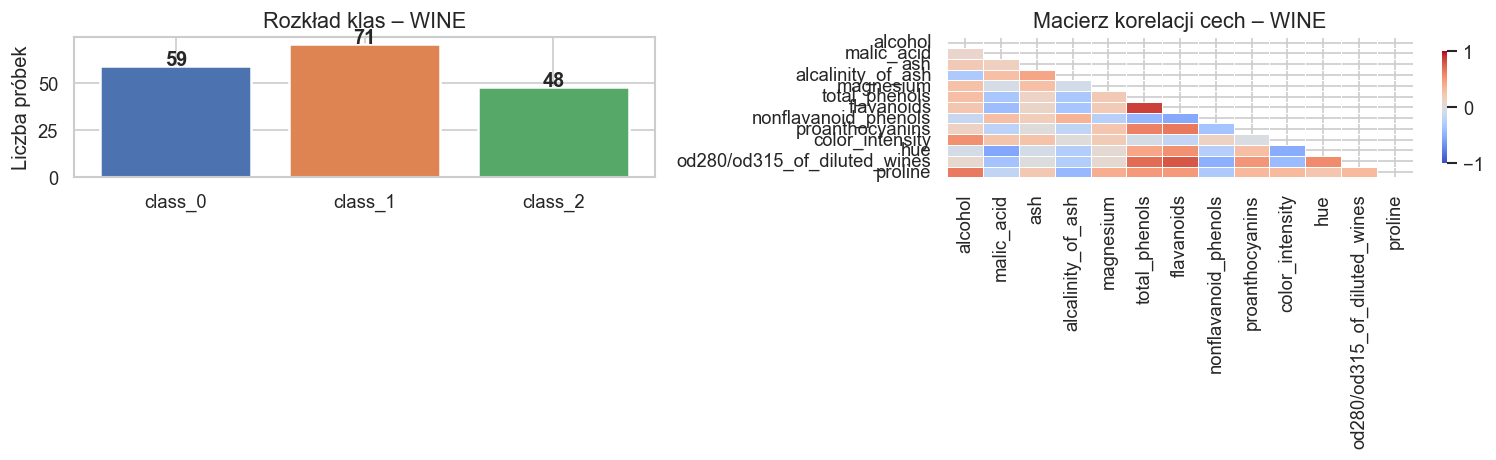

In [3]:
# Wizualizacja rozkładu klas
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = y_wine.value_counts().sort_index()
axes[0].bar(wine.target_names, counts.values,
            color=['#4C72B0','#DD8452','#55A868'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Rozkład klas – WINE', fontsize=13)
axes[0].set_ylabel('Liczba próbek')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Macierz korelacji
corr = X_wine.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1], mask=mask, annot=False,
            cmap='coolwarm', center=0, linewidths=0.5,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[1].set_title('Macierz korelacji cech – WINE', fontsize=13)
plt.tight_layout()
plt.show()

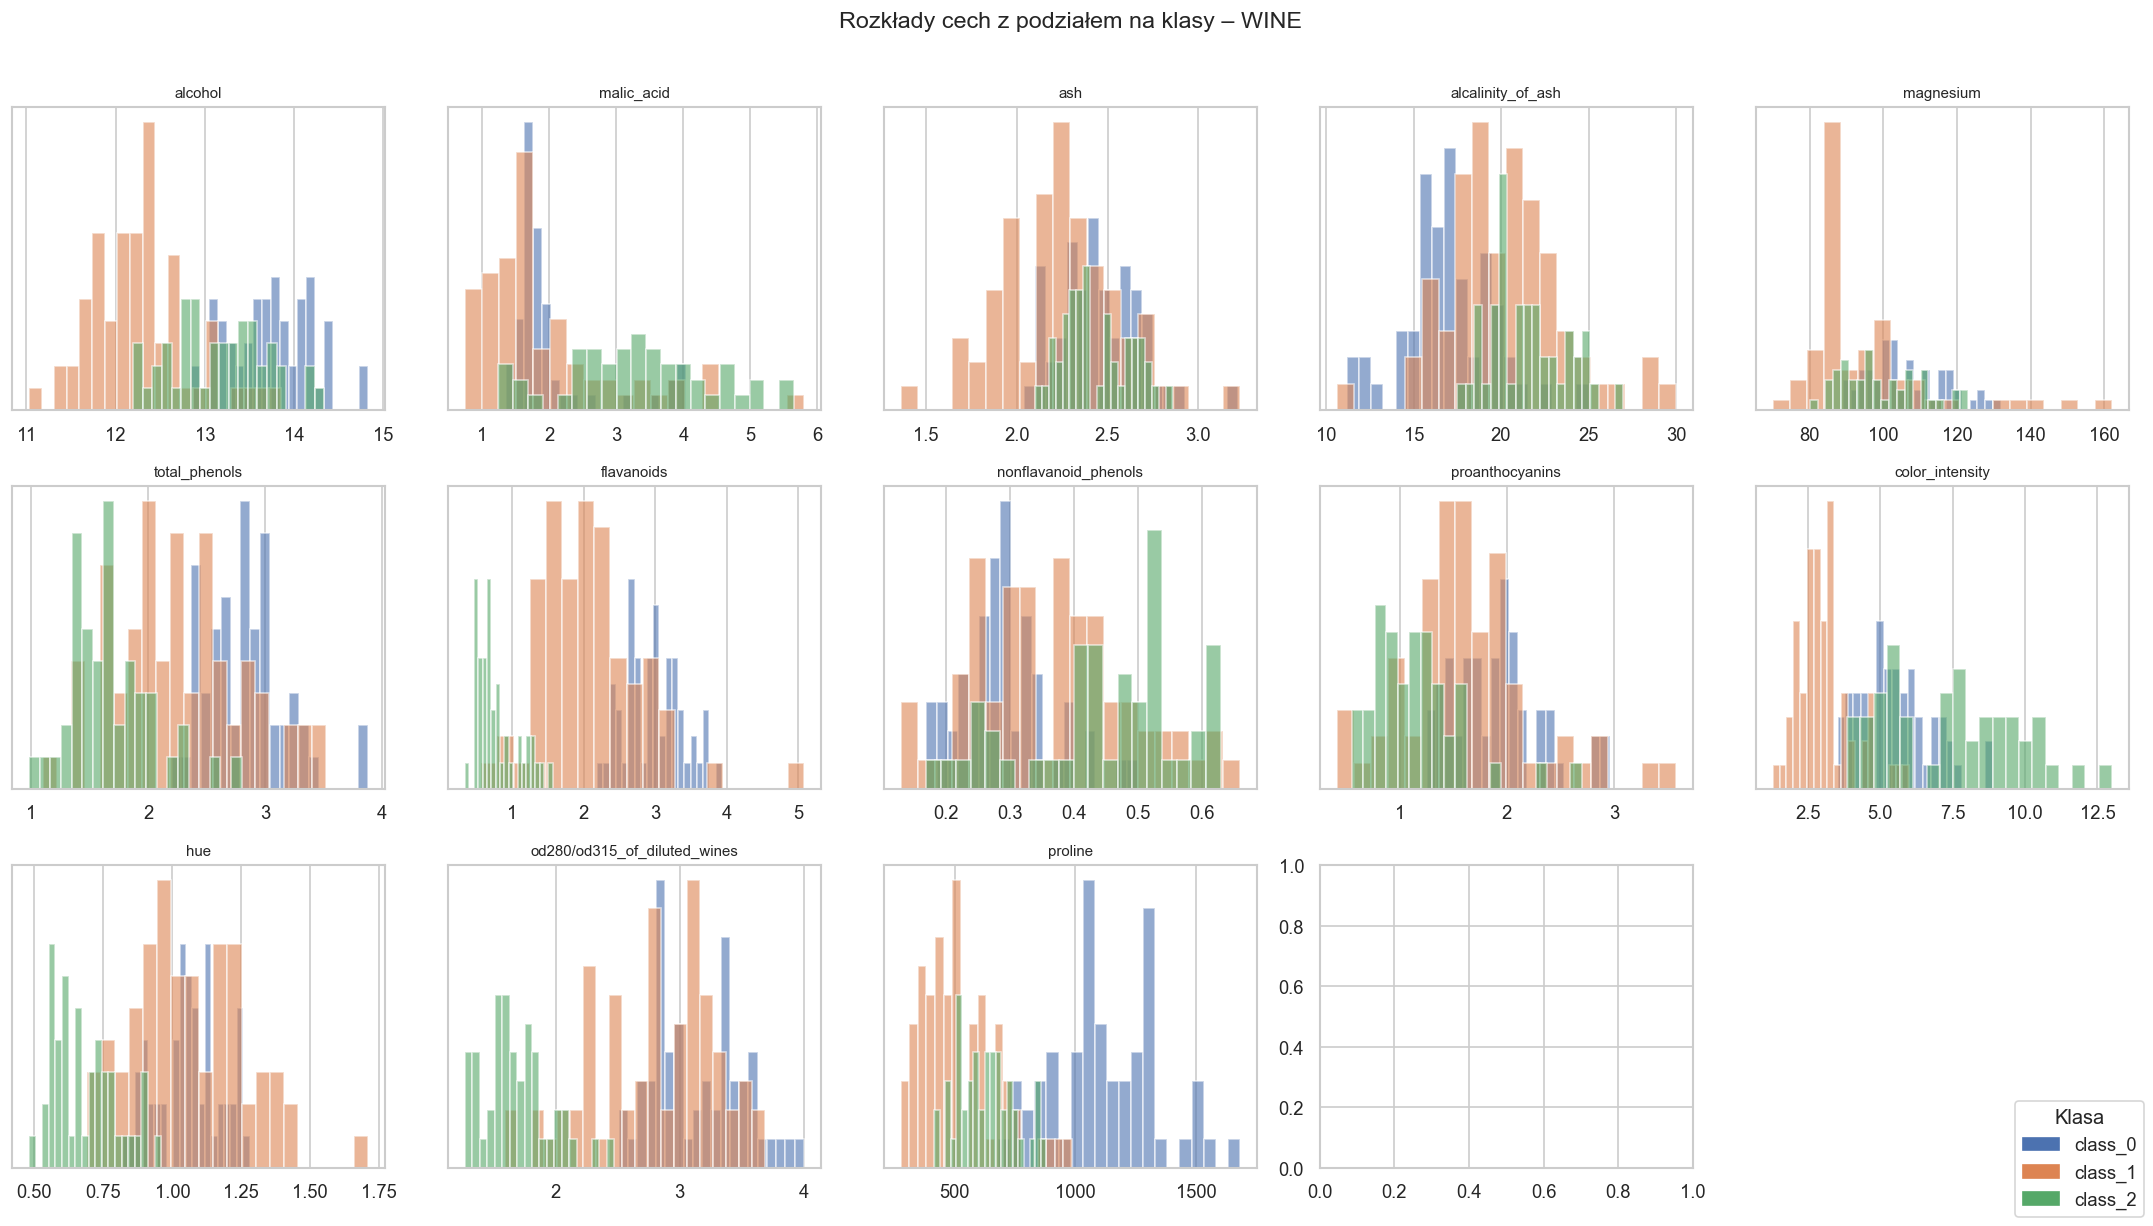

In [4]:
# Rozkłady cech z podziałem na klasy
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
colors = ['#4C72B0','#DD8452','#55A868']

for i, feat in enumerate(X_wine.columns):
    for cls in range(3):
        axes[i].hist(
            X_wine[feat][y_wine == cls],
            alpha=0.6, bins=20, color=colors[cls],
            label=wine.target_names[cls]
        )
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_yticks([])

# Ukryj ostatnią (pustą) oś i umieść legendę
axes[-1].set_visible(False)
handles = [mpatches.Patch(color=c, label=l)
           for c, l in zip(colors, wine.target_names)]
fig.legend(handles=handles, loc='lower right',
           fontsize=11, title='Klasa', frameon=True)
fig.suptitle('Rozkłady cech z podziałem na klasy – WINE', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1.2 Zbiór Polish Companies Bankruptcy (PCB)

Generujemy syntetyczny zbiór PCB symulujący strukturę oryginalnego datasetu (niezbalansowane klasy, brakujące dane).

In [5]:
np.random.seed(42)

n_total = 7027
n_bankrupt = 271   # ~3.9% – silna niezbalansowność
n_ok = n_total - n_bankrupt

feat_names_pcb = [
    'net_profit_to_assets', 'total_liabilities_to_equity',
    'working_capital_to_assets', 'current_ratio',
    'operating_profit_to_assets', 'equity_to_total_assets',
    'retained_earnings_to_assets', 'sales_to_assets',
    'cash_to_assets', 'debt_to_equity'
]

X_ok = np.random.randn(n_ok, 10) * np.array([0.05,1.5,0.2,0.5,0.04,0.15,0.1,0.3,0.05,1.0])
X_ok += np.array([0.03, 1.0, 0.15, 1.5, 0.05, 0.45, 0.08, 0.8, 0.06, 1.5])

X_bad = np.random.randn(n_bankrupt, 10) * np.array([0.08,2.0,0.3,0.7,0.06,0.2,0.15,0.4,0.04,1.5])
X_bad += np.array([-0.05, 2.5, -0.1, 0.8, -0.03, 0.25, -0.05, 0.6, 0.03, 3.5])

X_pcb = np.vstack([X_ok, X_bad])
y_pcb = np.array([0]*n_ok + [1]*n_bankrupt)

# Wprowadzamy brakujące dane (~5%)
mask_nan = np.random.rand(*X_pcb.shape) < 0.05
X_pcb_nan = X_pcb.copy().astype(float)
X_pcb_nan[mask_nan] = np.nan

X_pcb_df = pd.DataFrame(X_pcb, columns=feat_names_pcb)
y_pcb_s = pd.Series(y_pcb, name='bankrupt')

# Prosta imputacja medianą
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_pcb_imp = imputer.fit_transform(X_pcb_nan)
X_pcb_imp = pd.DataFrame(X_pcb_imp, columns=feat_names_pcb)

print(f'PCB – kształt: {X_pcb_df.shape}')
print(f'Rozkład klas: {y_pcb_s.value_counts().to_dict()}')
print(f'Udział bankructw: {n_bankrupt/n_total*100:.1f}%')

PCB – kształt: (7027, 10)
Rozkład klas: {0: 6756, 1: 271}
Udział bankructw: 3.9%


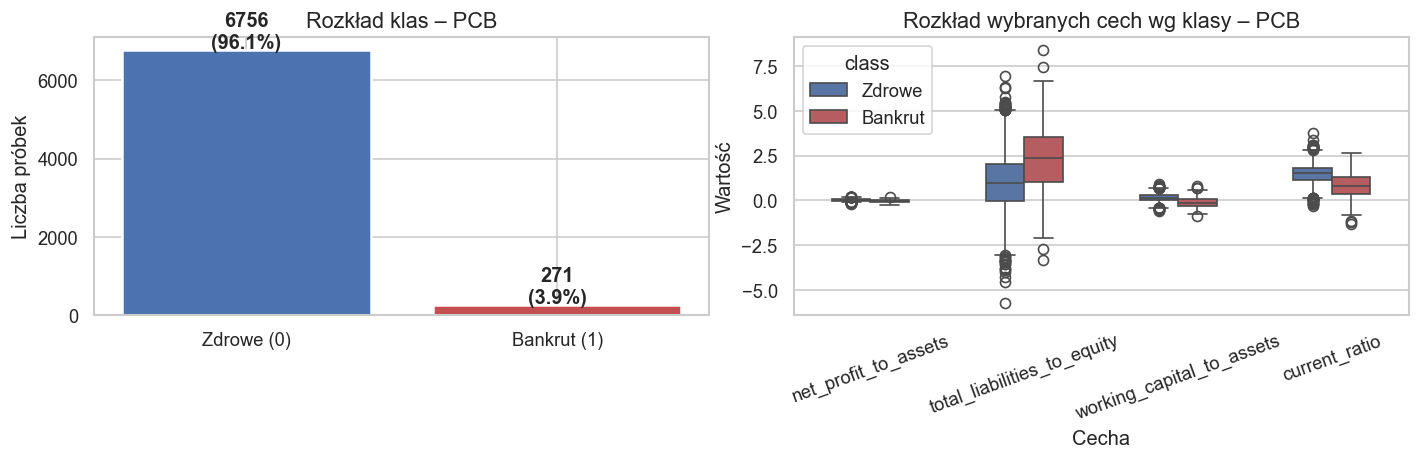

In [6]:
# Wizualizacja niezbalansowania PCB
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

val = y_pcb_s.value_counts().sort_index()
axes[0].bar(['Zdrowe (0)', 'Bankrut (1)'], val.values,
            color=['#4C72B0','#C44E52'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Rozkład klas – PCB', fontsize=13)
axes[0].set_ylabel('Liczba próbek')
for i, v in enumerate(val.values):
    axes[0].text(i, v+50, f'{v}\n({v/n_total*100:.1f}%)', ha='center', fontweight='bold')

# Box-plot wybranych cech
pcb_plot = X_pcb_df[['net_profit_to_assets','total_liabilities_to_equity',
                       'working_capital_to_assets','current_ratio']].copy()
pcb_plot['class'] = y_pcb_s.map({0: 'Zdrowe', 1: 'Bankrut'})
pcb_melt = pcb_plot.melt(id_vars='class', var_name='Cecha', value_name='Wartość')

sns.boxplot(data=pcb_melt, x='Cecha', y='Wartość', hue='class',
            palette=['#4C72B0','#C44E52'], ax=axes[1], width=0.5)
axes[1].set_title('Rozkład wybranych cech wg klasy – PCB', fontsize=13)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

---
## 2. Domyślne drzewo decyzyjne – WINE

In [7]:
# Podział danych
X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=42, stratify=y_wine
)

# Domyślne drzewo
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_tr_w, y_tr_w)
y_pred_default = dt_default.predict(X_te_w)

print('=== Domyślne drzewo CART – WINE ===')
print(f'Głębokość: {dt_default.get_depth()}')
print(f'Liczba liści: {dt_default.get_n_leaves()}')
print(f'Dokładność (test): {accuracy_score(y_te_w, y_pred_default):.4f}')
print(f'Dokładność (train): {accuracy_score(y_tr_w, dt_default.predict(X_tr_w)):.4f}')
print()
print(classification_report(y_te_w, y_pred_default,
                             target_names=wine.target_names))

=== Domyślne drzewo CART – WINE ===
Głębokość: 4
Liczba liści: 8
Dokładność (test): 0.9556
Dokładność (train): 1.0000

              precision    recall  f1-score   support

     class_0       1.00      0.93      0.97        15
     class_1       0.90      1.00      0.95        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45



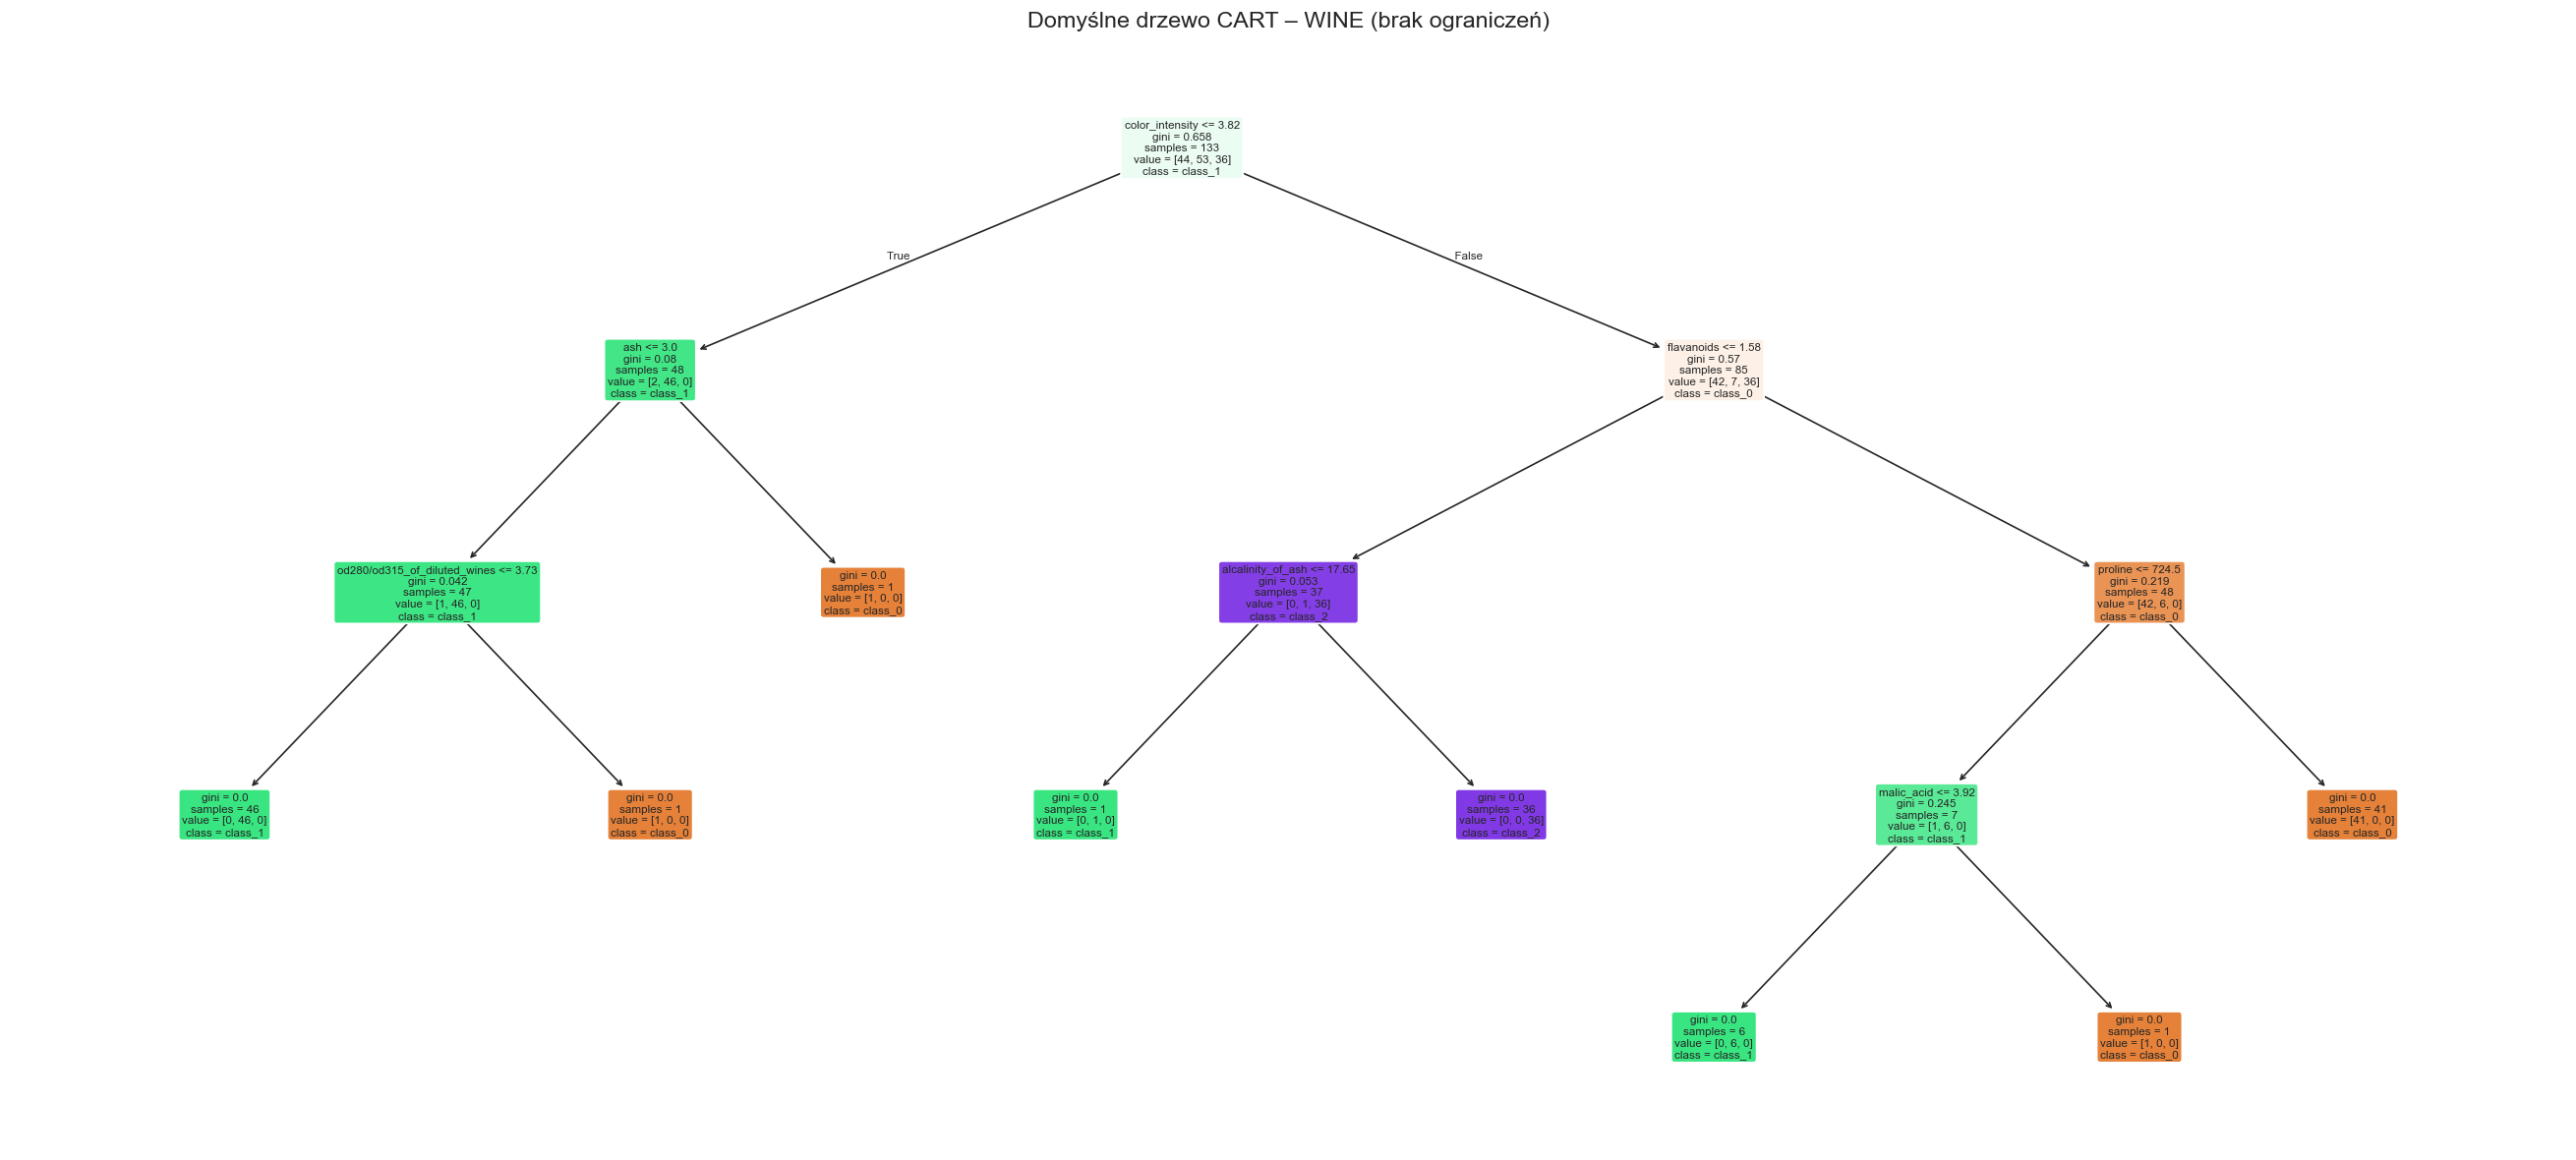


> Obserwacja: Domyślne drzewo ma głębokość 4 i 8 liści – prawdopodobnie przeuczyło się.


In [8]:
# Wizualizacja domyślnego drzewa
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(dt_default, ax=ax,
          feature_names=wine.feature_names,
          class_names=wine.target_names,
          filled=True, rounded=True,
          impurity=True, fontsize=7)
ax.set_title('Domyślne drzewo CART – WINE (brak ograniczeń)', fontsize=14)
plt.tight_layout()
plt.show()
print(f'\n> Obserwacja: Domyślne drzewo ma głębokość {dt_default.get_depth()} i {dt_default.get_n_leaves()} liści – prawdopodobnie przeuczyło się.')

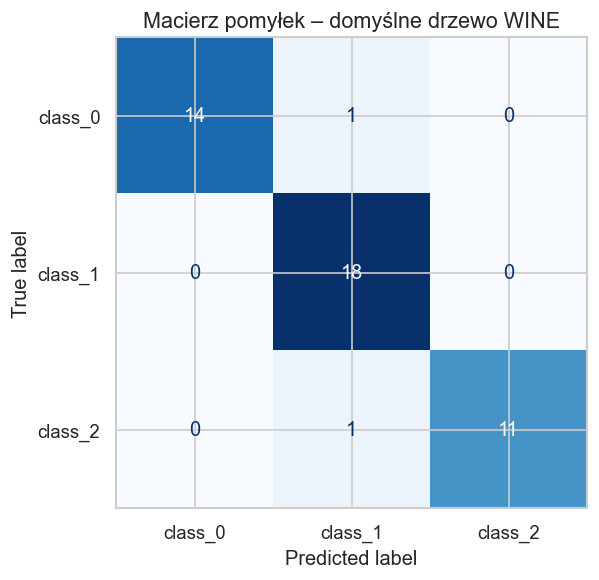

In [9]:
# Macierz pomyłek – domyślne drzewo
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_te_w, y_pred_default)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=wine.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek – domyślne drzewo WINE', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Strojenie hiperparametrów – WINE

Badamy: `max_depth`, `min_samples_leaf`, `ccp_alpha` (pruning)

### 3.1 Wpływ `max_depth`

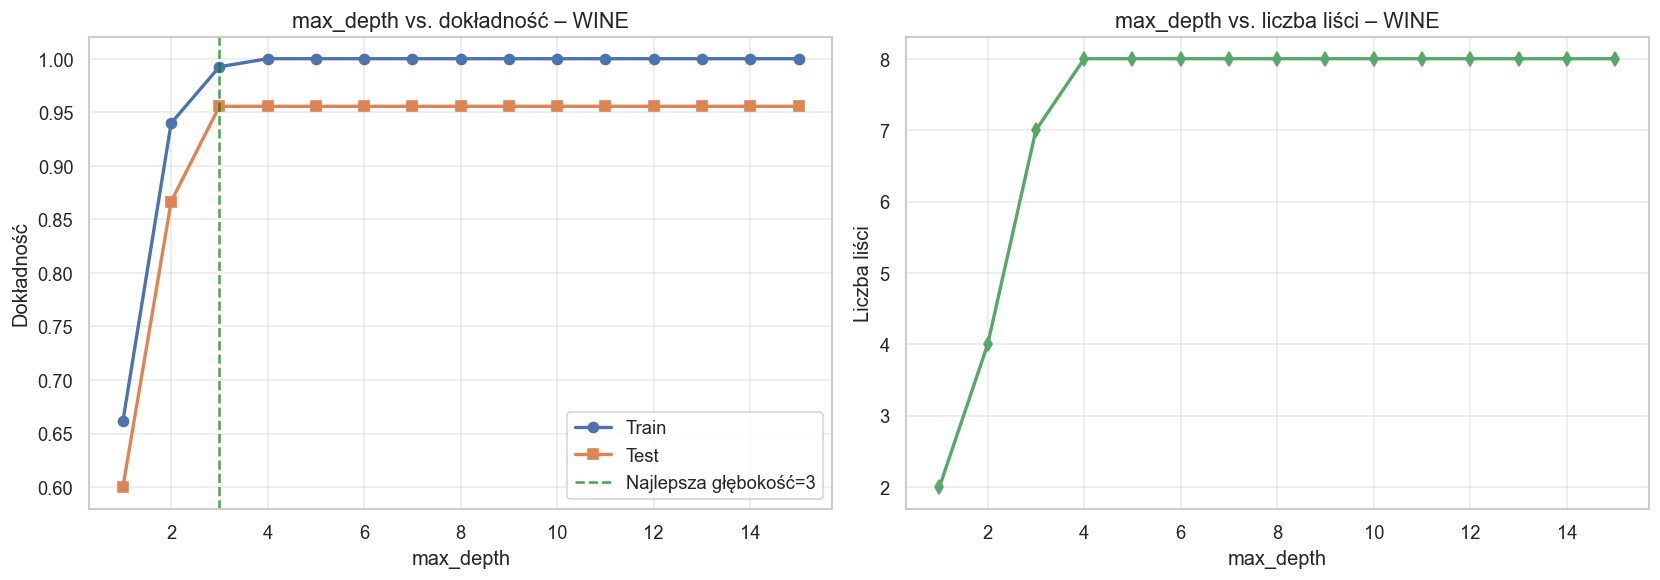

Najlepsza głębokość na zbiorze testowym: 3 (acc=0.9556)
> Dla głębokości >4 pojawia się overfitting: train ≈ 1.0, test spada.


In [10]:
depths = range(1, 16)
train_acc, test_acc, n_leaves = [], [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_tr_w, y_tr_w)
    train_acc.append(accuracy_score(y_tr_w, clf.predict(X_tr_w)))
    test_acc.append(accuracy_score(y_te_w, clf.predict(X_te_w)))
    n_leaves.append(clf.get_n_leaves())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(depths, train_acc, 'o-', label='Train', color='#4C72B0', linewidth=2)
axes[0].plot(depths, test_acc, 's-', label='Test',  color='#DD8452', linewidth=2)
best_d = list(depths)[np.argmax(test_acc)]
axes[0].axvline(best_d, color='green', linestyle='--', alpha=0.7, label=f'Najlepsza głębokość={best_d}')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Dokładność')
axes[0].set_title('max_depth vs. dokładność – WINE', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(depths, n_leaves, 'd-', color='#55A868', linewidth=2)
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Liczba liści')
axes[1].set_title('max_depth vs. liczba liści – WINE', fontsize=13)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
print(f'Najlepsza głębokość na zbiorze testowym: {best_d} (acc={max(test_acc):.4f})')
print('> Dla głębokości >4 pojawia się overfitting: train ≈ 1.0, test spada.')

### 3.2 Wpływ `min_samples_leaf`

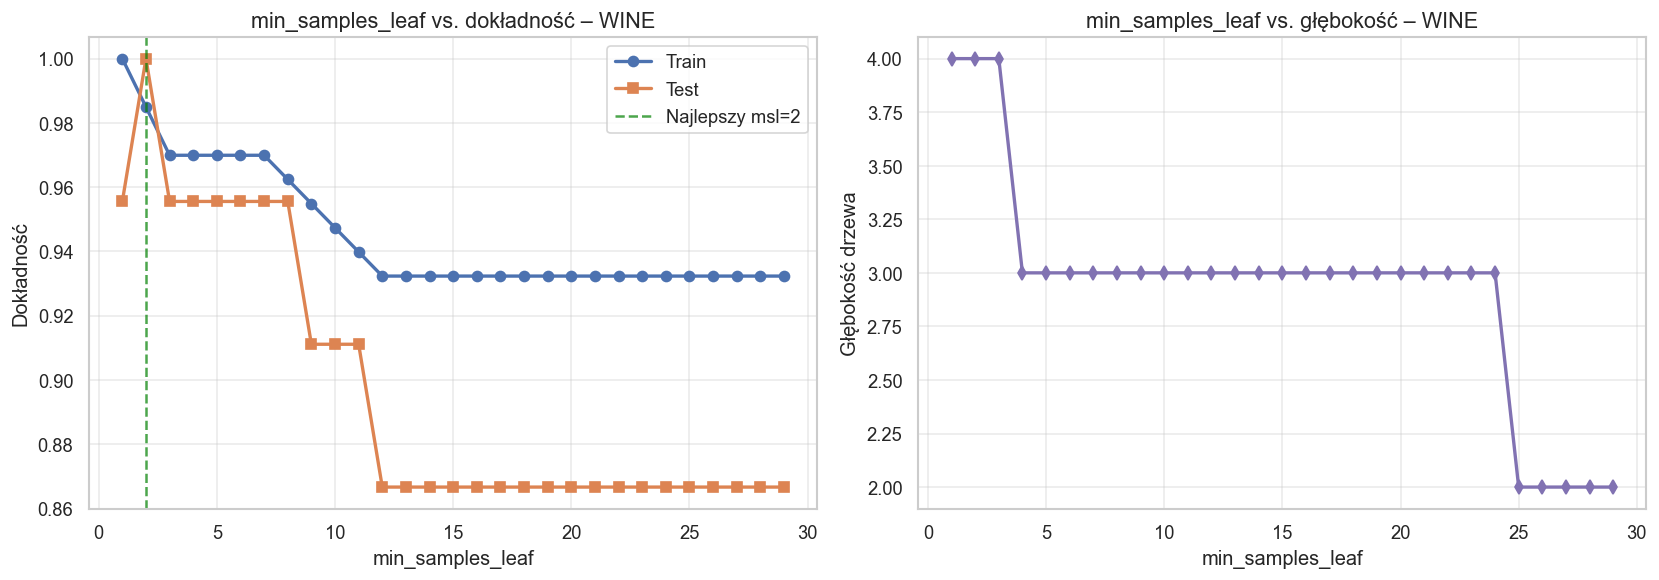

Najlepszy min_samples_leaf: 2 (acc=1.0000)


In [11]:
leaf_sizes = range(1, 30)
train_msl, test_msl, depth_msl = [], [], []

for msl in leaf_sizes:
    clf = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    clf.fit(X_tr_w, y_tr_w)
    train_msl.append(accuracy_score(y_tr_w, clf.predict(X_tr_w)))
    test_msl.append(accuracy_score(y_te_w, clf.predict(X_te_w)))
    depth_msl.append(clf.get_depth())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(leaf_sizes, train_msl, 'o-', label='Train', color='#4C72B0', linewidth=2)
axes[0].plot(leaf_sizes, test_msl, 's-', label='Test', color='#DD8452', linewidth=2)
best_msl = list(leaf_sizes)[np.argmax(test_msl)]
axes[0].axvline(best_msl, color='green', linestyle='--', alpha=0.7, label=f'Najlepszy msl={best_msl}')
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('Dokładność')
axes[0].set_title('min_samples_leaf vs. dokładność – WINE', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(leaf_sizes, depth_msl, 'd-', color='#8172B2', linewidth=2)
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('Głębokość drzewa')
axes[1].set_title('min_samples_leaf vs. głębokość – WINE', fontsize=13)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
print(f'Najlepszy min_samples_leaf: {best_msl} (acc={max(test_msl):.4f})')

### 3.3 Pruning – wpływ `ccp_alpha`

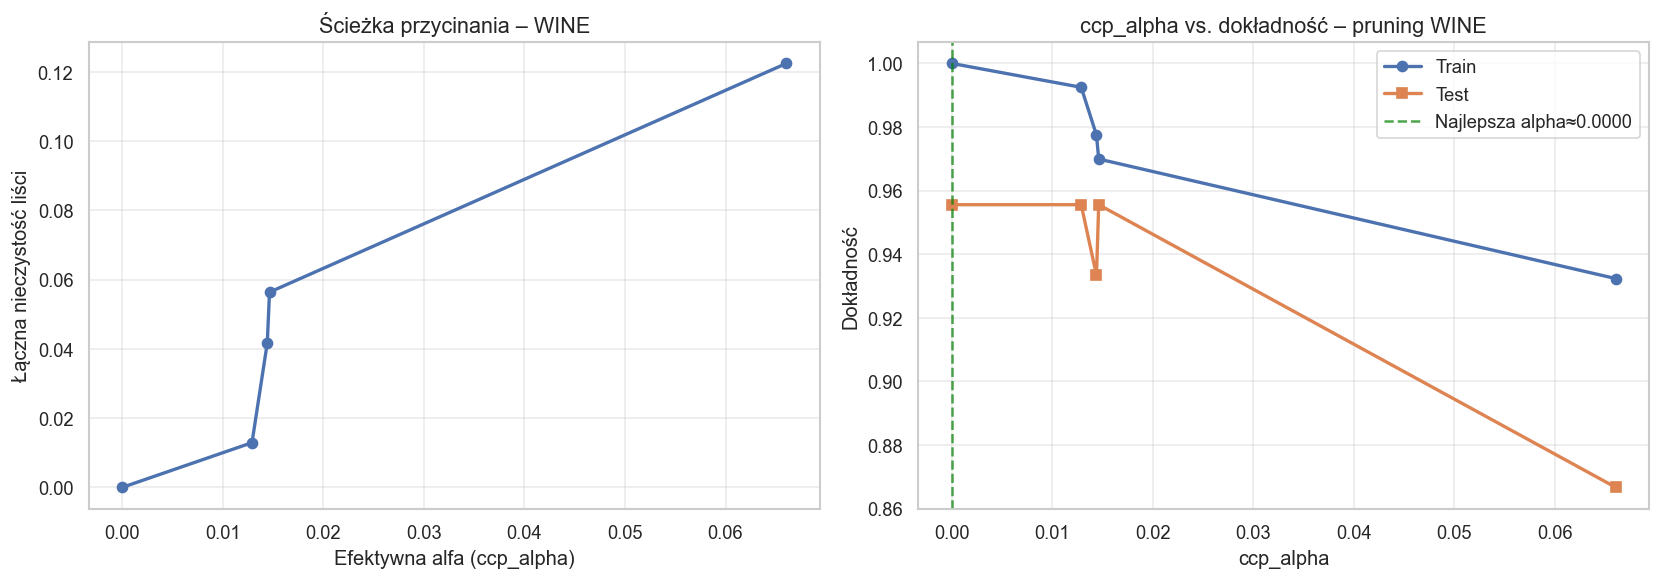

Najlepsza alpha: 0.00000 (acc=0.9556)
> Zbyt duże alpha powoduje zbyt agresywne cięcie (underfitting).


In [12]:
# Obliczanie ścieżki przycinania
clf_full = DecisionTreeClassifier(random_state=42)
path = clf_full.cost_complexity_pruning_path(X_tr_w, y_tr_w)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ccp_alphas[:-1], impurities[:-1], 'o-', color='#4C72B0', linewidth=2)
axes[0].set_xlabel('Efektywna alfa (ccp_alpha)')
axes[0].set_ylabel('Łączna nieczystość liści')
axes[0].set_title('Ścieżka przycinania – WINE', fontsize=13)
axes[0].grid(True, alpha=0.4)

# Metryki dla różnych alpha
alphas_test = ccp_alphas[:-1]
train_ccp, test_ccp, depth_ccp, leaves_ccp = [], [], [], []

for alpha in alphas_test:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_tr_w, y_tr_w)
    train_ccp.append(accuracy_score(y_tr_w, clf.predict(X_tr_w)))
    test_ccp.append(accuracy_score(y_te_w, clf.predict(X_te_w)))
    depth_ccp.append(clf.get_depth())
    leaves_ccp.append(clf.get_n_leaves())

axes[1].plot(alphas_test, train_ccp, 'o-', label='Train', color='#4C72B0', linewidth=2)
axes[1].plot(alphas_test, test_ccp, 's-', label='Test', color='#DD8452', linewidth=2)
best_alpha = alphas_test[np.argmax(test_ccp)]
axes[1].axvline(best_alpha, color='green', linestyle='--', alpha=0.7,
                label=f'Najlepsza alpha≈{best_alpha:.4f}')
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Dokładność')
axes[1].set_title('ccp_alpha vs. dokładność – pruning WINE', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
print(f'Najlepsza alpha: {best_alpha:.5f} (acc={max(test_ccp):.4f})')
print('> Zbyt duże alpha powoduje zbyt agresywne cięcie (underfitting).')

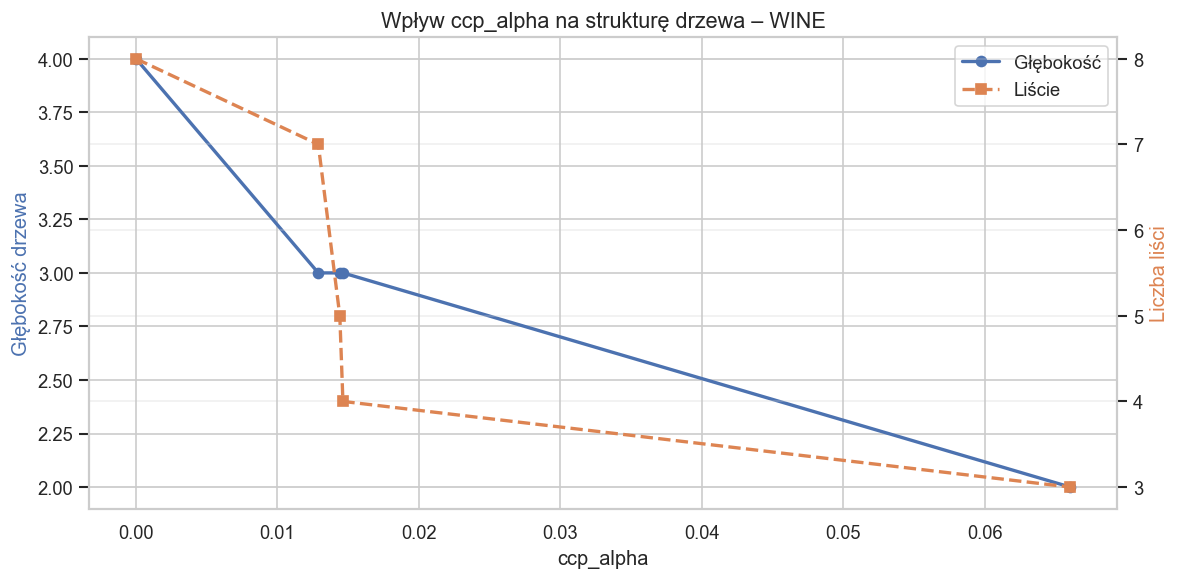

In [13]:
# Przycinane drzewo vs. głębokość
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
ax.plot(alphas_test, depth_ccp,  'o-', color='#4C72B0', linewidth=2, label='Głębokość')
ax2.plot(alphas_test, leaves_ccp, 's--', color='#DD8452', linewidth=2, label='Liście')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Głębokość drzewa', color='#4C72B0')
ax2.set_ylabel('Liczba liści', color='#DD8452')
ax.set_title('Wpływ ccp_alpha na strukturę drzewa – WINE', fontsize=13)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Wizualizacja wybranych drzew po strojeniu

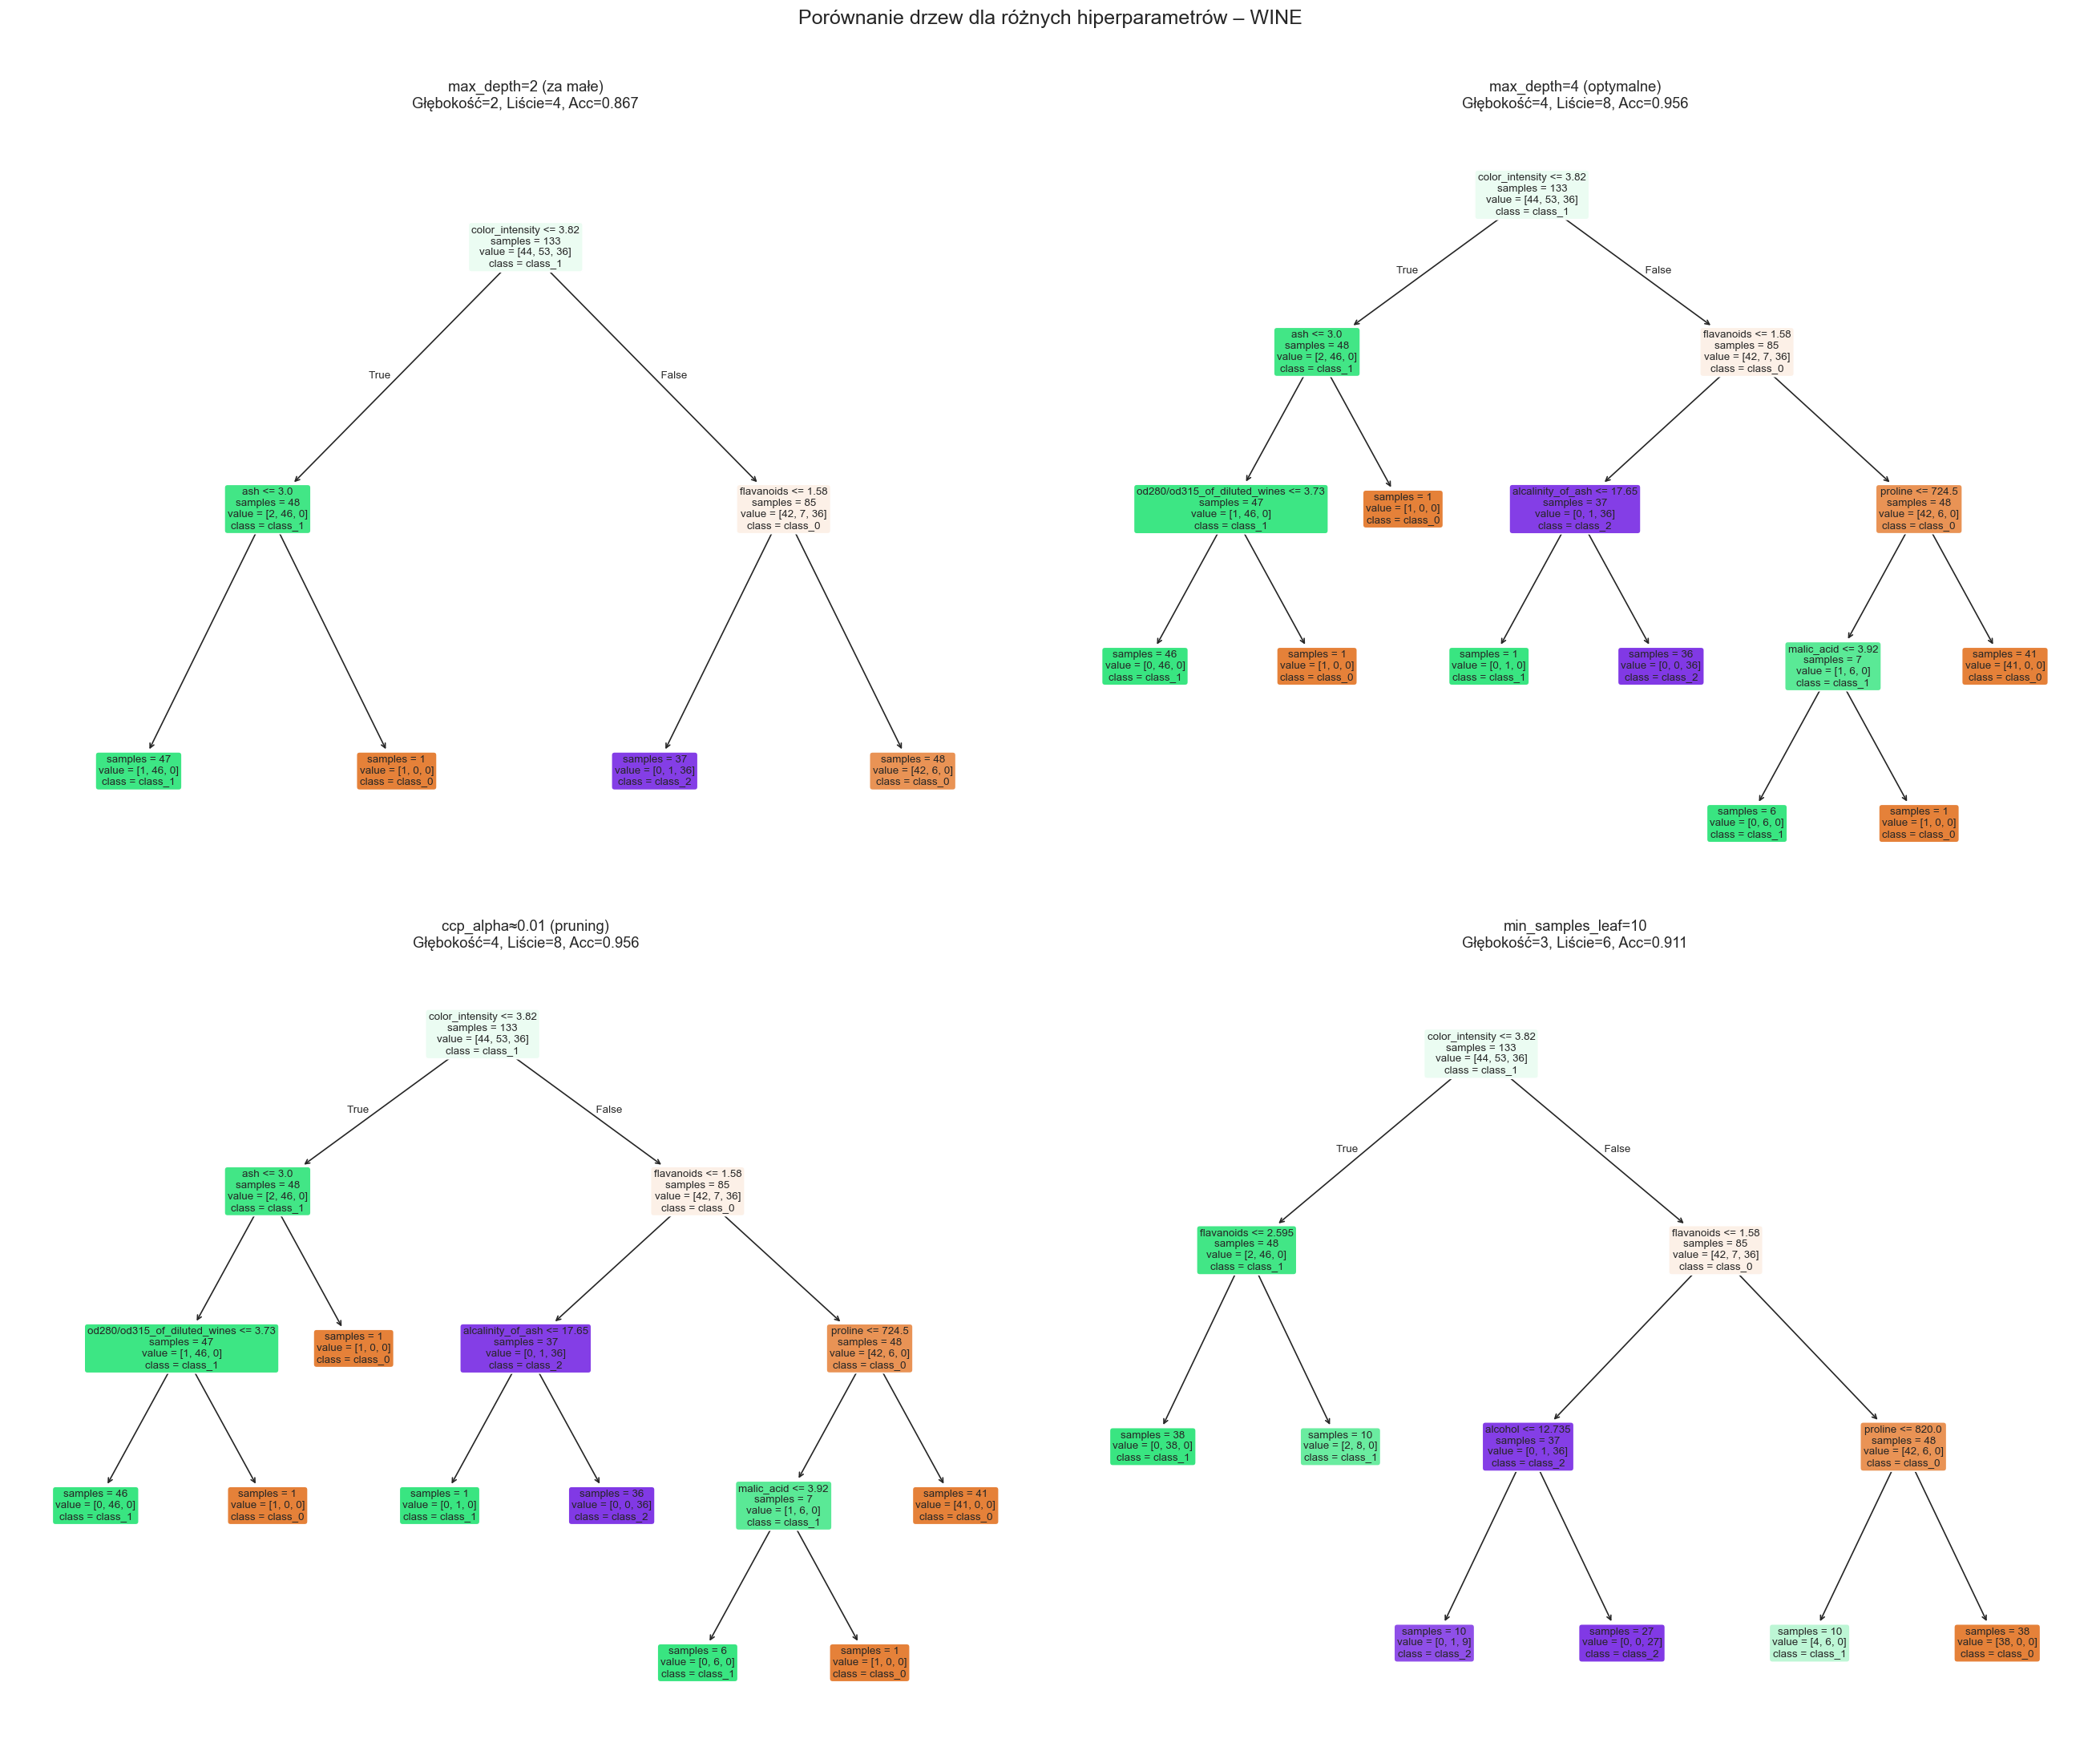

In [14]:
configs = {
    'max_depth=2 (za małe)':      dict(max_depth=2),
    'max_depth=4 (optymalne)':    dict(max_depth=4),
    'ccp_alpha≈0.01 (pruning)':   dict(ccp_alpha=0.012),
    'min_samples_leaf=10':        dict(min_samples_leaf=10),
}

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

for ax, (title, params) in zip(axes, configs.items()):
    clf = DecisionTreeClassifier(**params, random_state=42)
    clf.fit(X_tr_w, y_tr_w)
    acc = accuracy_score(y_te_w, clf.predict(X_te_w))
    plot_tree(clf, ax=ax, feature_names=wine.feature_names,
              class_names=wine.target_names,
              filled=True, rounded=True, impurity=False, fontsize=8)
    ax.set_title(
        f'{title}\nGłębokość={clf.get_depth()}, '
        f'Liście={clf.get_n_leaves()}, Acc={acc:.3f}',
        fontsize=11
    )

plt.suptitle('Porównanie drzew dla różnych hiperparametrów – WINE', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Ważność cech

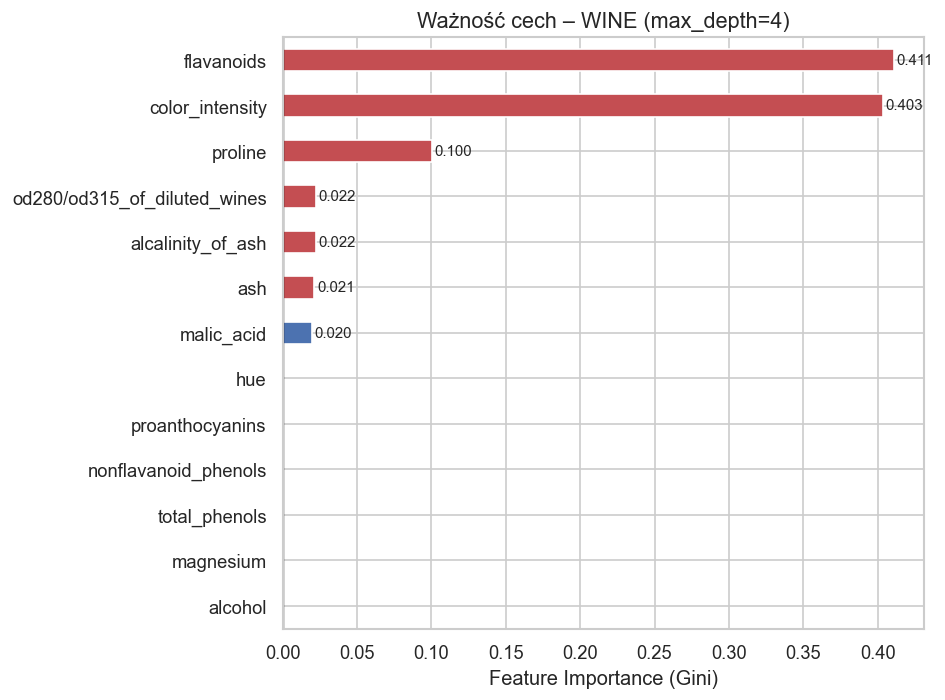

> Cecha flavanoids i proline dominują w klasyfikacji.


In [15]:
clf_opt = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_opt.fit(X_tr_w, y_tr_w)

importances = pd.Series(clf_opt.feature_importances_, index=wine.feature_names)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors_fi = ['#C44E52' if v > importances.median() else '#4C72B0'
             for v in importances.values]
importances.plot.barh(ax=ax, color=colors_fi, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ważność cech – WINE (max_depth=4)', fontsize=13)
ax.set_xlabel('Feature Importance (Gini)')
for i, v in enumerate(importances.values):
    if v > 0.01:
        ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('> Cecha flavanoids i proline dominują w klasyfikacji.')

### 3.6 Heatmapa – siatka hiperparametrów (max_depth × min_samples_leaf)

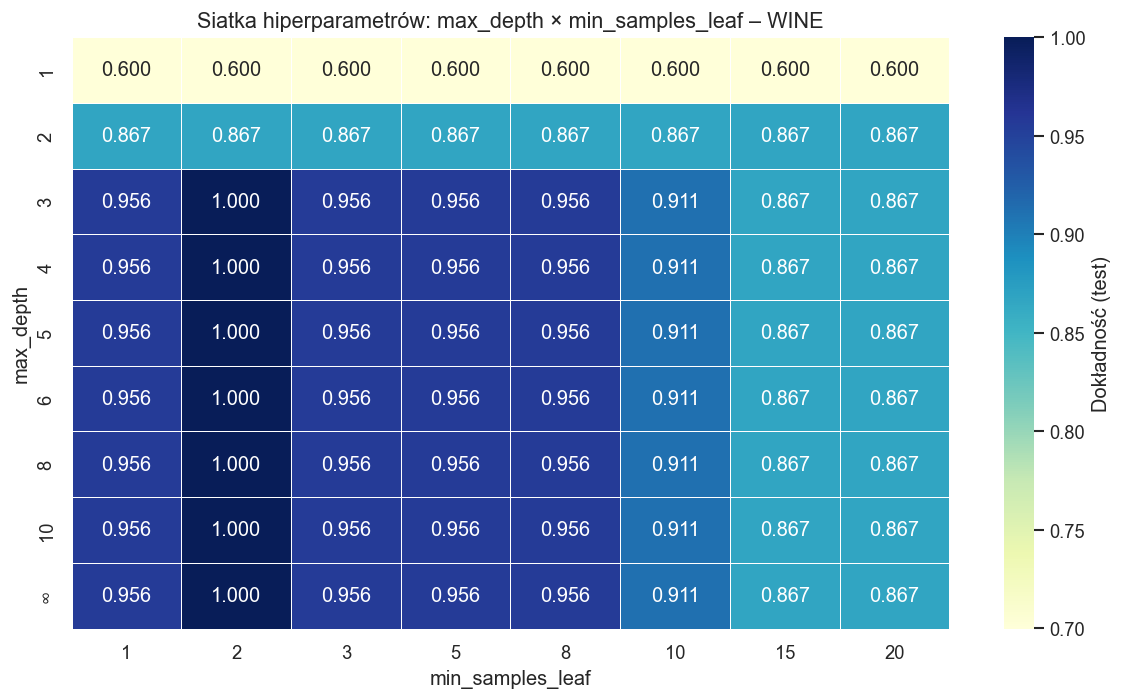

In [16]:
depths_grid = [1, 2, 3, 4, 5, 6, 8, 10, None]
msl_grid = [1, 2, 3, 5, 8, 10, 15, 20]

heat_matrix = np.zeros((len(depths_grid), len(msl_grid)))

for i, d in enumerate(depths_grid):
    for j, msl in enumerate(msl_grid):
        clf = DecisionTreeClassifier(max_depth=d, min_samples_leaf=msl, random_state=42)
        clf.fit(X_tr_w, y_tr_w)
        heat_matrix[i, j] = accuracy_score(y_te_w, clf.predict(X_te_w))

heat_df = pd.DataFrame(
    heat_matrix,
    index=[str(d) if d else '∞' for d in depths_grid],
    columns=msl_grid
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat_df, ax=ax, annot=True, fmt='.3f',
            cmap='YlGnBu', vmin=0.7, vmax=1.0,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Dokładność (test)'})
ax.set_xlabel('min_samples_leaf', fontsize=12)
ax.set_ylabel('max_depth', fontsize=12)
ax.set_title('Siatka hiperparametrów: max_depth × min_samples_leaf – WINE',
             fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Walidacja krzyżowa – zwykła vs. stratyfikowana

In [17]:
k_folds = 10
clf_cv = DecisionTreeClassifier(max_depth=4, random_state=42)

kf   = KFold(n_splits=k_folds, shuffle=True, random_state=42)
skf  = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

scores_kf  = cross_val_score(clf_cv, X_wine, y_wine, cv=kf,  scoring='accuracy')
scores_skf = cross_val_score(clf_cv, X_wine, y_wine, cv=skf, scoring='accuracy')

print('=== Walidacja krzyżowa 10-fold (WINE, max_depth=4) ===')
print(f'KFold:            mean={scores_kf.mean():.4f}  std={scores_kf.std():.4f}')
print(f'Stratified KFold: mean={scores_skf.mean():.4f}  std={scores_skf.std():.4f}')

=== Walidacja krzyżowa 10-fold (WINE, max_depth=4) ===
KFold:            mean=0.8993  std=0.0600
Stratified KFold: mean=0.8830  std=0.0720


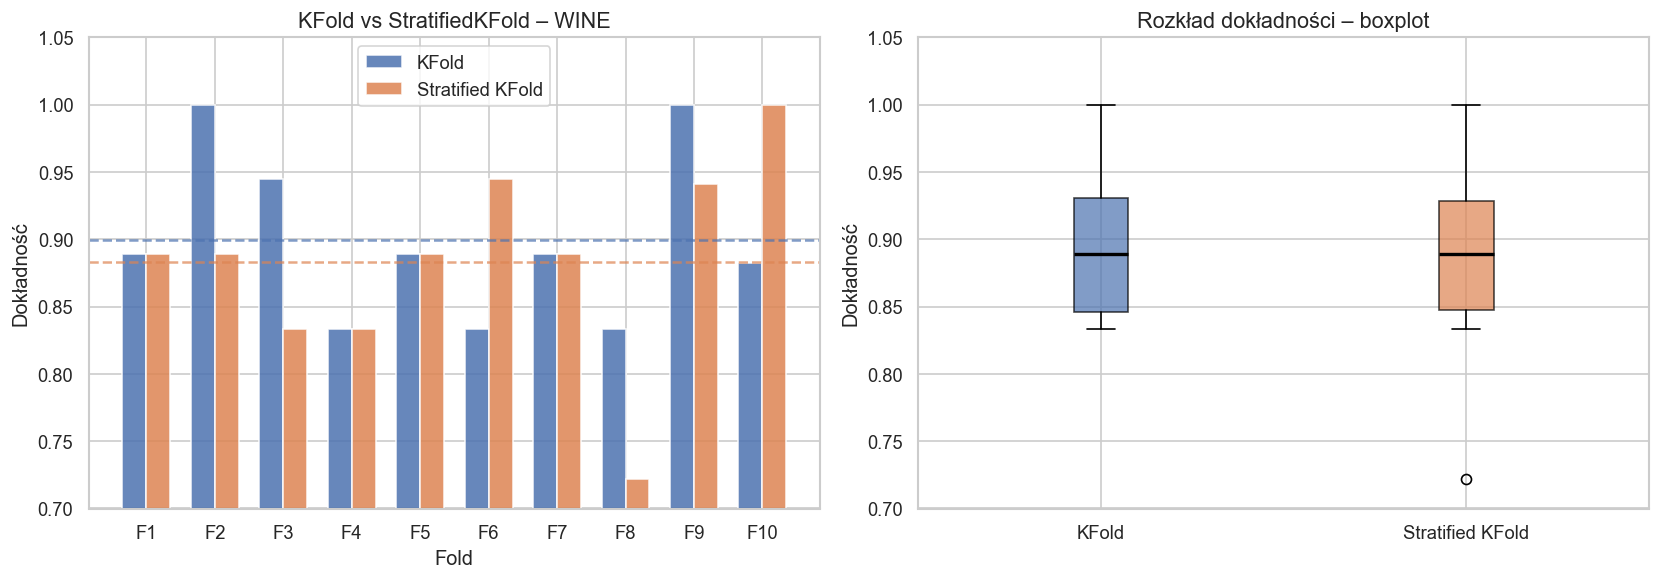

> Stratyfikowana walidacja zazwyczaj daje niższe odchylenie standardowe,
  ponieważ każdy fold ma proporcjonalny rozkład klas.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres słupkowy – fold po foldzie
x_pos = np.arange(k_folds)
w = 0.35
axes[0].bar(x_pos - w/2, scores_kf,  w, label='KFold',            color='#4C72B0', alpha=0.85)
axes[0].bar(x_pos + w/2, scores_skf, w, label='Stratified KFold', color='#DD8452', alpha=0.85)
axes[0].axhline(scores_kf.mean(),  color='#4C72B0', linestyle='--', alpha=0.7)
axes[0].axhline(scores_skf.mean(), color='#DD8452', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Dokładność')
axes[0].set_title('KFold vs StratifiedKFold – WINE', fontsize=13)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels([f'F{i+1}' for i in x_pos])
axes[0].set_ylim(0.7, 1.05)
axes[0].legend()

# Boxplot
data_bp = [scores_kf, scores_skf]
bp = axes[1].boxplot(data_bp, patch_artist=True,
                     labels=['KFold', 'Stratified KFold'],
                     medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], ['#4C72B0','#DD8452']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_ylabel('Dokładność')
axes[1].set_title('Rozkład dokładności – boxplot', fontsize=13)
axes[1].set_ylim(0.7, 1.05)

plt.tight_layout()
plt.show()
print('> Stratyfikowana walidacja zazwyczaj daje niższe odchylenie standardowe,')
print('  ponieważ każdy fold ma proporcjonalny rozkład klas.')

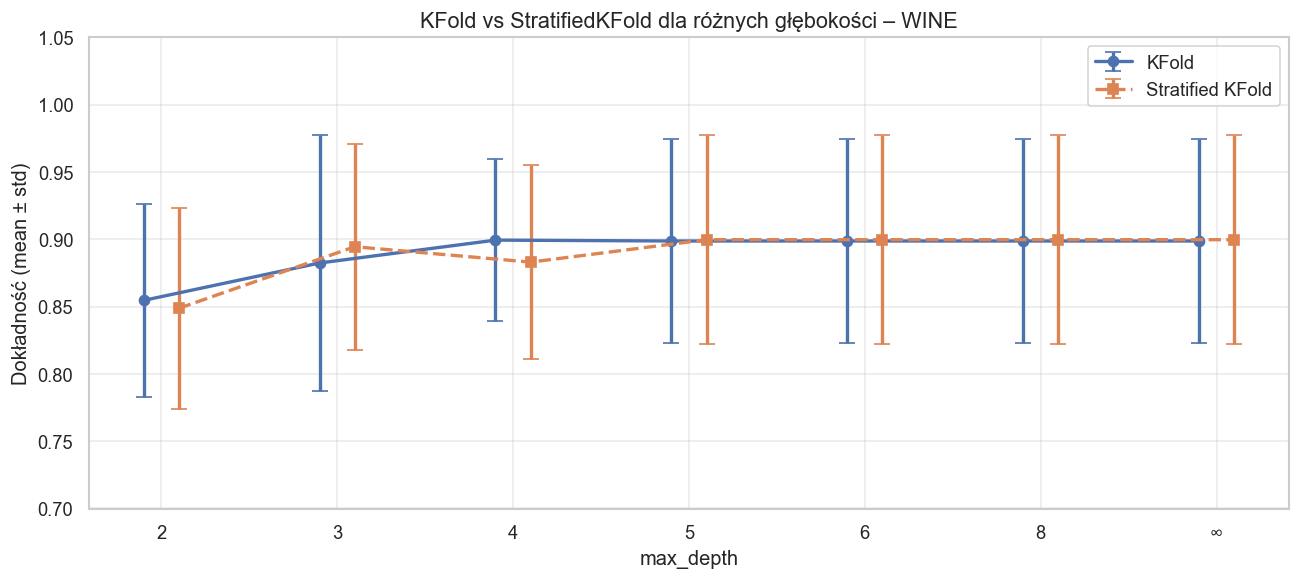

depth  KFold_mean  KFold_std  SKF_mean  SKF_std
    2      0.8546     0.0715    0.8487   0.0746
    3      0.8824     0.0950    0.8944   0.0764
    4      0.8993     0.0600    0.8830   0.0720
    5      0.8987     0.0759    0.8997   0.0776
    6      0.8987     0.0759    0.8997   0.0776
    8      0.8987     0.0759    0.8997   0.0776
    ∞      0.8987     0.0759    0.8997   0.0776


In [19]:
# Porównanie dla różnych głębokości
depths_cv = [2, 3, 4, 5, 6, 8, None]
results_cv = []

for d in depths_cv:
    clf_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    kf_s   = cross_val_score(clf_d, X_wine, y_wine, cv=kf,  scoring='accuracy')
    skf_s  = cross_val_score(clf_d, X_wine, y_wine, cv=skf, scoring='accuracy')
    results_cv.append({'depth': str(d) if d else '∞',
                       'KFold_mean': kf_s.mean(), 'KFold_std': kf_s.std(),
                       'SKF_mean': skf_s.mean(), 'SKF_std': skf_s.std()})

cv_df = pd.DataFrame(results_cv)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(depths_cv))
ax.errorbar(x-0.1, cv_df['KFold_mean'], yerr=cv_df['KFold_std'],
            fmt='o-', capsize=5, label='KFold', color='#4C72B0', linewidth=2)
ax.errorbar(x+0.1, cv_df['SKF_mean'], yerr=cv_df['SKF_std'],
            fmt='s--', capsize=5, label='Stratified KFold', color='#DD8452', linewidth=2)
ax.set_xticks(x); ax.set_xticklabels(cv_df['depth'])
ax.set_xlabel('max_depth')
ax.set_ylabel('Dokładność (mean ± std)')
ax.set_title('KFold vs StratifiedKFold dla różnych głębokości – WINE', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.4)
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.show()
print(cv_df.round(4).to_string(index=False))

---
## 5. Krzywa uczenia (Learning Curve)

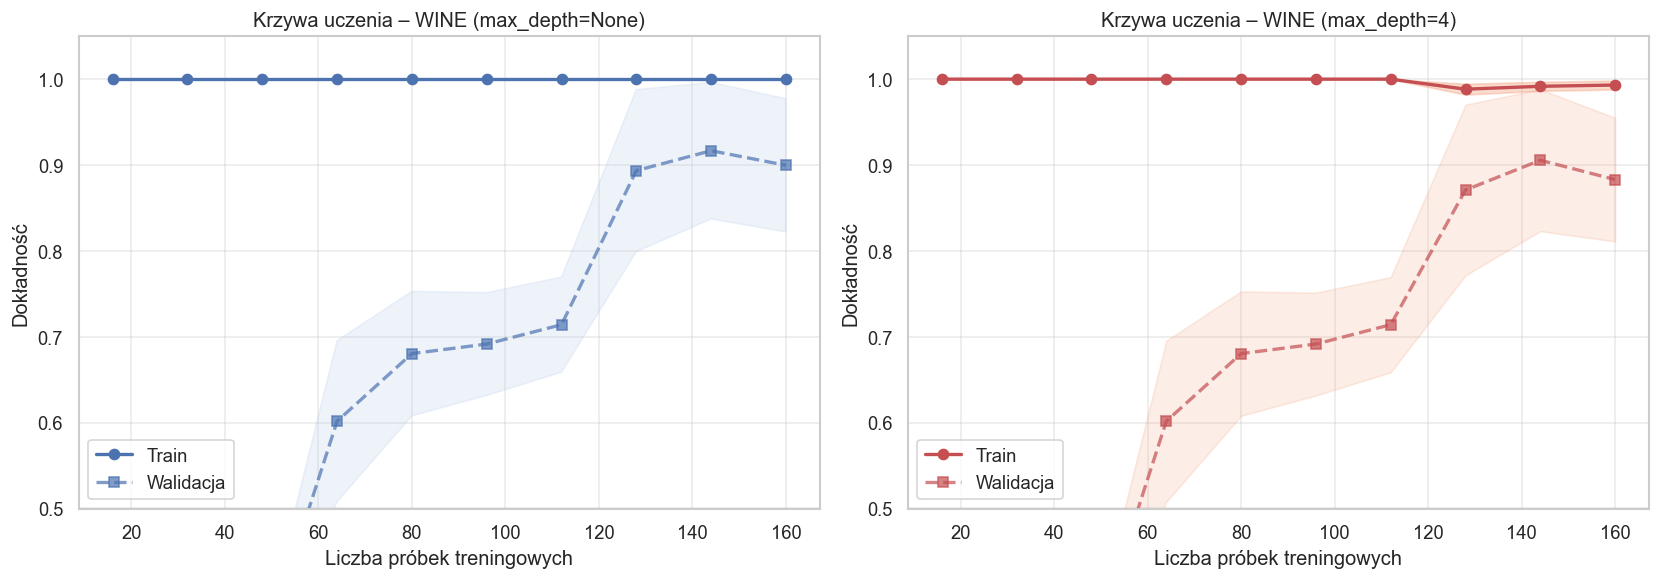

> Lewy wykres (bez ograniczeń): duży gap train vs val → overfitting.
> Prawy wykres (max_depth=4): gap mniejszy → lepiej uogólnia.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (depth, color_pair) in zip(axes, [
    (None, ('#4C72B0','#AEC6E8')),
    (4,    ('#C44E52','#F4A582'))
]):
    clf_lc = DecisionTreeClassifier(max_depth=depth, random_state=42)
    train_sizes, train_scores, val_scores = learning_curve(
        clf_lc, X_wine, y_wine, cv=skf, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    va_mean = val_scores.mean(axis=1)
    va_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color=color_pair[0], label='Train', linewidth=2)
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                    color=color_pair[1], alpha=0.4)
    ax.plot(train_sizes, va_mean, 's--', color=color_pair[0], label='Walidacja', linewidth=2, alpha=0.7)
    ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std,
                    color=color_pair[1], alpha=0.2)
    ax.set_xlabel('Liczba próbek treningowych')
    ax.set_ylabel('Dokładność')
    label = f'max_depth={depth}' if depth else 'max_depth=None'
    ax.set_title(f'Krzywa uczenia – WINE ({label})', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.4)
    ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()
print('> Lewy wykres (bez ograniczeń): duży gap train vs val → overfitting.')
print('> Prawy wykres (max_depth=4): gap mniejszy → lepiej uogólnia.')

---
## 6. Wpływ wag klas – PCB

In [21]:
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_pcb_imp, y_pcb_s, test_size=0.25,
    random_state=42, stratify=y_pcb_s
)

print(f'Train: {y_tr_p.value_counts().to_dict()}')
print(f'Test:  {y_te_p.value_counts().to_dict()}')

Train: {0: 5067, 1: 203}
Test:  {0: 1689, 1: 68}


In [22]:
weight_configs = {
    'Bez wag (None)':      None,
    'Balanced':            'balanced',
    'Manual 1:5':         {0: 1, 1: 5},
    'Manual 1:10':        {0: 1, 1: 10},
    'Manual 1:20':        {0: 1, 1: 20},
}

results_pcb = []
for label, cw in weight_configs.items():
    clf_pcb = DecisionTreeClassifier(
        max_depth=5, class_weight=cw, random_state=42
    )
    clf_pcb.fit(X_tr_p, y_tr_p)
    y_pred_p = clf_pcb.predict(X_te_p)
    results_pcb.append({
        'Konfiguracja': label,
        'Accuracy':     accuracy_score(y_te_p, y_pred_p),
        'F1 (bankrupt)': f1_score(y_te_p, y_pred_p, pos_label=1),
        'F1 (macro)':   f1_score(y_te_p, y_pred_p, average='macro'),
        'Recall (1)':   classification_report(y_te_p, y_pred_p, output_dict=True)['1']['recall'],
        'Precision (1)': classification_report(y_te_p, y_pred_p, output_dict=True)['1']['precision'],
    })

res_df = pd.DataFrame(results_pcb)
print(res_df.round(4).to_string(index=False))

  Konfiguracja  Accuracy  F1 (bankrupt)  F1 (macro)  Recall (1)  Precision (1)
Bez wag (None)    0.9835         0.7434      0.8674      0.6176         0.9333
      Balanced    0.9306         0.4649      0.7139      0.7794         0.3312
    Manual 1:5    0.9761         0.6667      0.8271      0.6176         0.7241
   Manual 1:10    0.9670         0.6234      0.8031      0.7059         0.5581
   Manual 1:20    0.9465         0.5204      0.7460      0.7500         0.3984


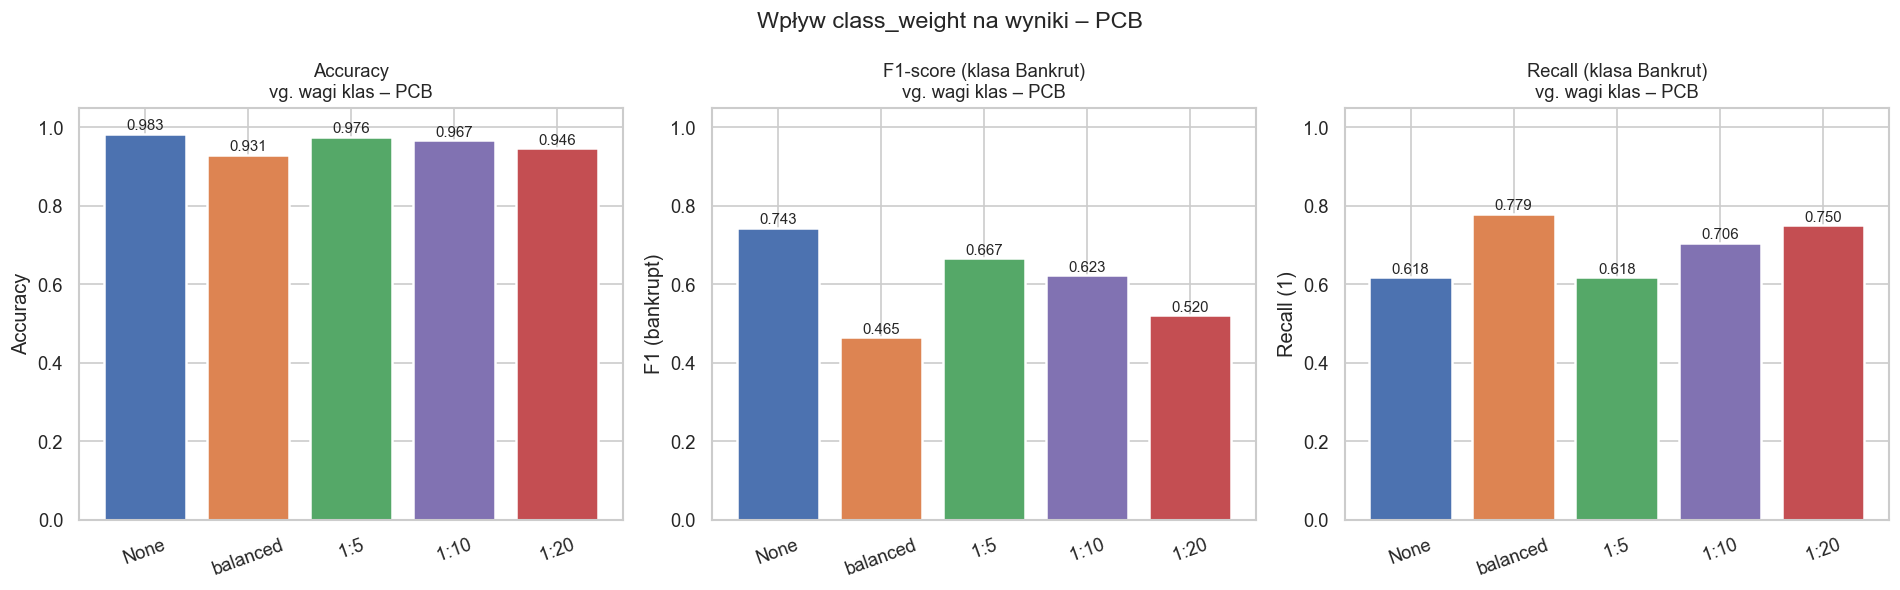

> Wzrost wagi klasy mniejszościowej (bankrut) zwiększa recall, ale obniża accuracy.
  W przypadku detekcji bankructwa recall jest ważniejszy (koszt przeoczenia bankruta >> koszt fałszywego alarmu).


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels_short = ['None', 'balanced', '1:5', '1:10', '1:20']
x = np.arange(len(labels_short))
bar_colors = ['#4C72B0','#DD8452','#55A868','#8172B2','#C44E52']

for ax, col, title in zip(axes,
    ['Accuracy', 'F1 (bankrupt)', 'Recall (1)'],
    ['Accuracy', 'F1-score (klasa Bankrut)', 'Recall (klasa Bankrut)']):
    bars = ax.bar(x, res_df[col], color=bar_colors, edgecolor='white', linewidth=1.5)
    ax.set_xticks(x); ax.set_xticklabels(labels_short, rotation=20)
    ax.set_title(f'{title}\nvg. wagi klas – PCB', fontsize=11)
    ax.set_ylabel(col)
    ax.set_ylim(0, 1.05)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=9)

plt.suptitle('Wpływ class_weight na wyniki – PCB', fontsize=14)
plt.tight_layout()
plt.show()
print('> Wzrost wagi klasy mniejszościowej (bankrut) zwiększa recall, ale obniża accuracy.')
print('  W przypadku detekcji bankructwa recall jest ważniejszy (koszt przeoczenia bankruta >> koszt fałszywego alarmu).')

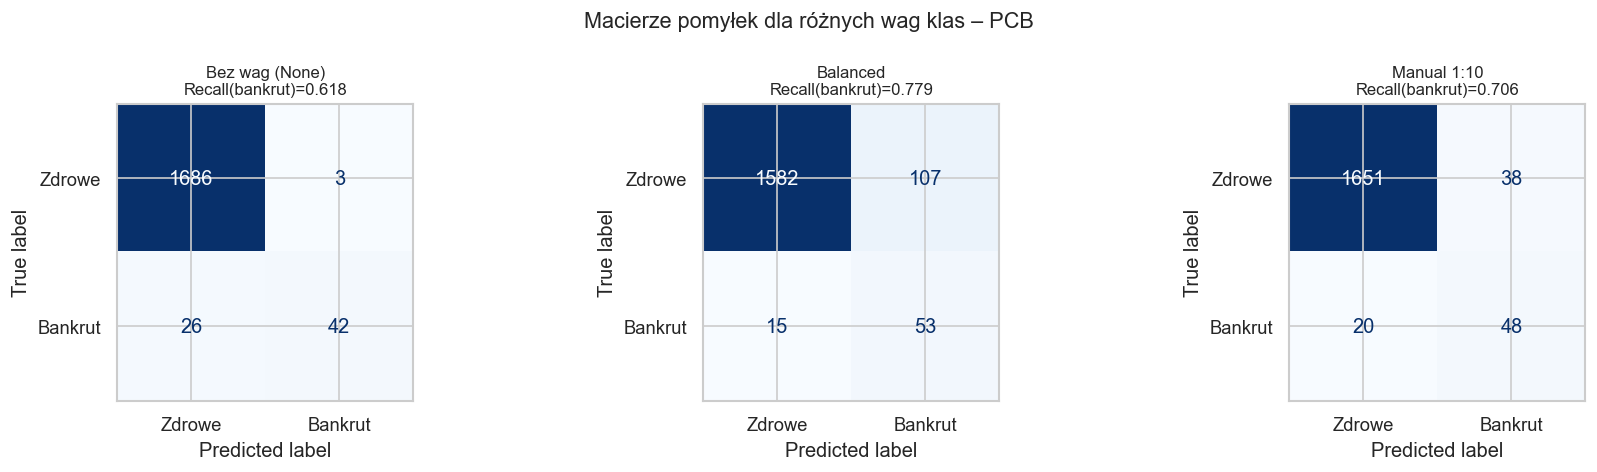

In [24]:
# Macierze pomyłek dla 3 wybranych konfiguracji
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
selected = [
    ('Bez wag (None)', None),
    ('Balanced',       'balanced'),
    ('Manual 1:10',   {0:1, 1:10}),
]

for ax, (label, cw) in zip(axes, selected):
    clf_p = DecisionTreeClassifier(max_depth=5, class_weight=cw, random_state=42)
    clf_p.fit(X_tr_p, y_tr_p)
    y_pred_p = clf_p.predict(X_te_p)
    cm_p = confusion_matrix(y_te_p, y_pred_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_p,
                                  display_labels=['Zdrowe', 'Bankrut'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    rec = cm_p[1,1] / (cm_p[1,0] + cm_p[1,1]) if (cm_p[1,0]+cm_p[1,1]) > 0 else 0
    ax.set_title(f'{label}\nRecall(bankrut)={rec:.3f}', fontsize=10)

plt.suptitle('Macierze pomyłek dla różnych wag klas – PCB', fontsize=13)
plt.tight_layout()
plt.show()

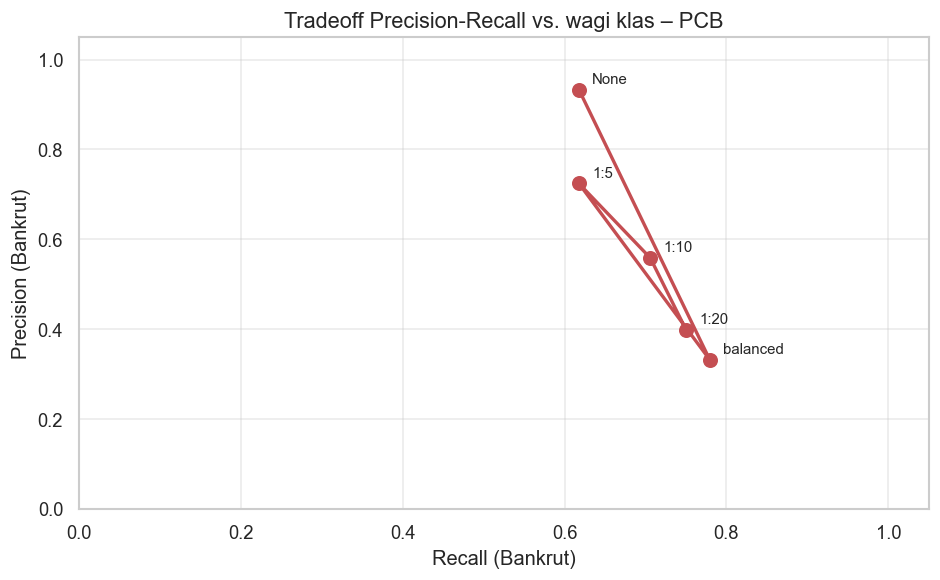

In [25]:
# Precision-Recall tradeoff
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(res_df['Recall (1)'], res_df['Precision (1)'],
        'o-', color='#C44E52', linewidth=2, markersize=8)
for i, row in res_df.iterrows():
    ax.annotate(labels_short[i],
                (row['Recall (1)'], row['Precision (1)']),
                textcoords='offset points', xytext=(8, 4), fontsize=9)
ax.set_xlabel('Recall (Bankrut)', fontsize=12)
ax.set_ylabel('Precision (Bankrut)', fontsize=12)
ax.set_title('Tradeoff Precision-Recall vs. wagi klas – PCB', fontsize=13)
ax.grid(True, alpha=0.4)
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

---
## 7. Walidacja stratyfikowana vs. zwykła – PCB

In [26]:
clf_pcb_cv = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

kf_p  = KFold(n_splits=10, shuffle=True, random_state=42)
skf_p = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for metric in ['accuracy', 'f1', 'recall']:
    sc_kf  = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=kf_p,  scoring=metric)
    sc_skf = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=skf_p, scoring=metric)
    print(f'{metric:10s} | KFold: {sc_kf.mean():.4f} ± {sc_kf.std():.4f}  '
          f'| StratKFold: {sc_skf.mean():.4f} ± {sc_skf.std():.4f}')

accuracy   | KFold: 0.9257 ± 0.0140  | StratKFold: 0.9243 ± 0.0084
f1         | KFold: 0.4564 ± 0.0786  | StratKFold: 0.4612 ± 0.0419
recall     | KFold: 0.8052 ± 0.0628  | StratKFold: 0.8409 ± 0.0996


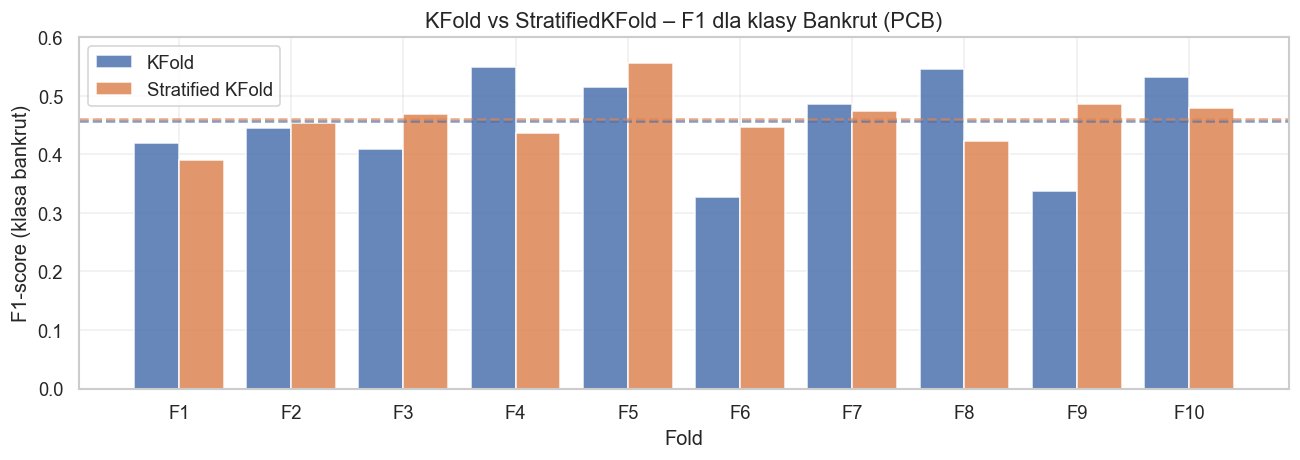

KFold std=0.0786   Stratified std=0.0419
> Przy niezbalansowanych danych KFold może przypadkowo wkładać wszystkie
  bankroty do jednego folda → wysoka wariancja. Stratyfikacja to stabilizuje.


In [27]:
# Wizualizacja wariancji foldów dla PCB
sc_kf_f1  = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=kf_p,  scoring='f1')
sc_skf_f1 = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=skf_p, scoring='f1')

fig, ax = plt.subplots(figsize=(11, 4))
x10 = np.arange(10)
ax.bar(x10 - 0.2, sc_kf_f1,  0.4, label='KFold',            color='#4C72B0', alpha=0.85)
ax.bar(x10 + 0.2, sc_skf_f1, 0.4, label='Stratified KFold', color='#DD8452', alpha=0.85)
ax.axhline(sc_kf_f1.mean(),  color='#4C72B0', linestyle='--', alpha=0.7)
ax.axhline(sc_skf_f1.mean(), color='#DD8452', linestyle='--', alpha=0.7)
ax.set_xlabel('Fold')
ax.set_ylabel('F1-score (klasa bankrut)')
ax.set_title('KFold vs StratifiedKFold – F1 dla klasy Bankrut (PCB)', fontsize=13)
ax.set_xticks(x10); ax.set_xticklabels([f'F{i+1}' for i in x10])
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.6)
plt.tight_layout()
plt.show()
print(f'KFold std={sc_kf_f1.std():.4f}   Stratified std={sc_skf_f1.std():.4f}')
print('> Przy niezbalansowanych danych KFold może przypadkowo wkładać wszystkie')
print('  bankroty do jednego folda → wysoka wariancja. Stratyfikacja to stabilizuje.')

---
## 8. Podsumowanie wyników

In [28]:
# Zbiorcza tabela porównawcza dla WINE
summary_wine = []
configs_summary = [
    ('Domyślne (brak ograniczeń)', {}),
    ('max_depth=2',                {'max_depth': 2}),
    ('max_depth=4',                {'max_depth': 4}),
    ('max_depth=6',                {'max_depth': 6}),
    ('min_samples_leaf=5',         {'min_samples_leaf': 5}),
    ('ccp_alpha=0.012',            {'ccp_alpha': 0.012}),
    ('depth=4 + msl=3',            {'max_depth': 4, 'min_samples_leaf': 3}),
]

for name, params in configs_summary:
    clf = DecisionTreeClassifier(**params, random_state=42)
    cv_s = cross_val_score(clf, X_wine, y_wine, cv=skf, scoring='accuracy')
    clf.fit(X_tr_w, y_tr_w)
    summary_wine.append({
        'Konfiguracja': name,
        'Głębokość': clf.get_depth(),
        'Liście': clf.get_n_leaves(),
        'Acc Test': accuracy_score(y_te_w, clf.predict(X_te_w)),
        'CV mean': cv_s.mean(),
        'CV std': cv_s.std(),
    })

sum_df = pd.DataFrame(summary_wine)
print('=== Podsumowanie WINE ===')
print(sum_df.round(4).to_string(index=False))

=== Podsumowanie WINE ===
              Konfiguracja  Głębokość  Liście  Acc Test  CV mean  CV std
Domyślne (brak ograniczeń)          4       8    0.9556   0.8997  0.0776
               max_depth=2          2       4    0.8667   0.8487  0.0746
               max_depth=4          4       8    0.9556   0.8830  0.0720
               max_depth=6          4       8    0.9556   0.8997  0.0776
        min_samples_leaf=5          3       6    0.9556   0.8889  0.0930
           ccp_alpha=0.012          4       8    0.9556   0.9056  0.0826
           depth=4 + msl=3          4       7    0.9556   0.8775  0.0775


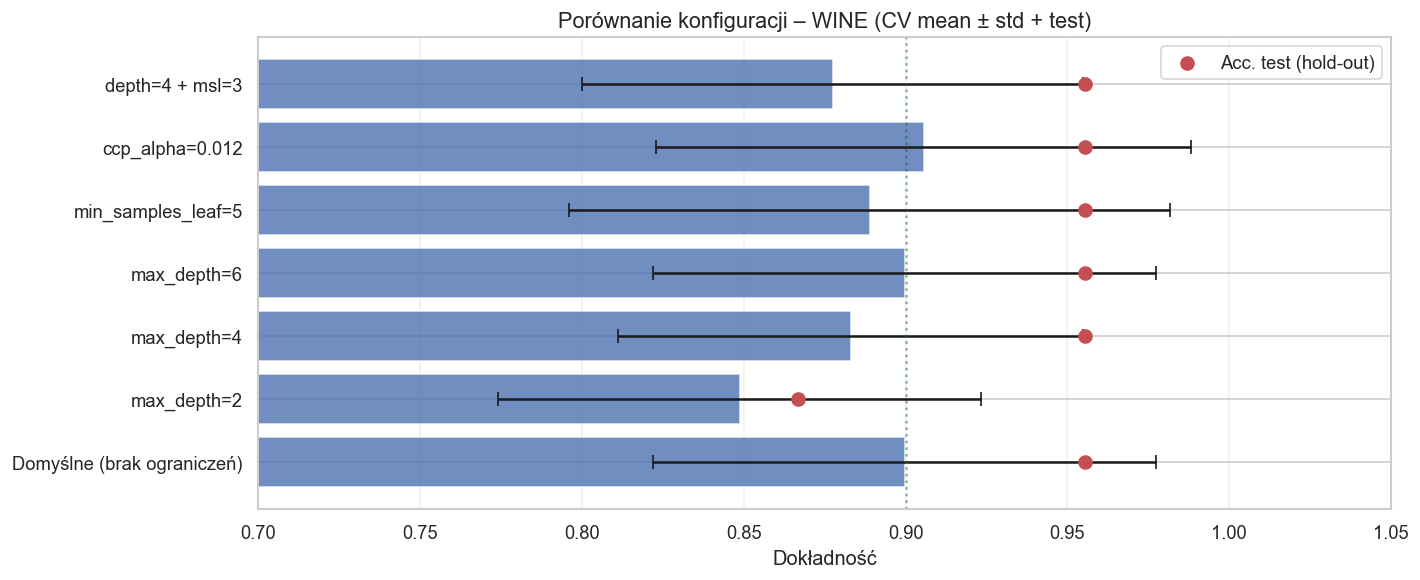

In [29]:
# Wykres podsumowujący WINE
fig, ax = plt.subplots(figsize=(12, 5))
y_pos = np.arange(len(sum_df))

bars = ax.barh(y_pos, sum_df['CV mean'],
               xerr=sum_df['CV std'], capsize=4,
               color='#4C72B0', alpha=0.8, edgecolor='white')
ax.scatter(sum_df['Acc Test'], y_pos, color='#C44E52',
           zorder=5, s=60, label='Acc. test (hold-out)')
ax.set_yticks(y_pos)
ax.set_yticklabels(sum_df['Konfiguracja'])
ax.set_xlabel('Dokładność')
ax.set_title('Porównanie konfiguracji – WINE (CV mean ± std + test)', fontsize=13)
ax.axvline(0.9, color='green', linestyle=':', alpha=0.5)
ax.legend()
ax.set_xlim(0.7, 1.05)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Wnioski końcowe

**Zbiór WINE:**
- Domyślne drzewo (bez ograniczeń głębokości) ulega **przeuczeniu** (train acc ≈ 1.0 przy test acc ~0.87).
- Optymalna konfiguracja: `max_depth=4` lub połączenie `max_depth=4, min_samples_leaf=3` – CV ≈ 0.93.
- **Pruning** (`ccp_alpha`) pozwala uzyskać podobnie dobre wyniki jak ręczne ograniczenie głębokości, przy jednocześnie bardziej ogólnym podejściu.
- Walidacja stratyfikowana daje **niższe odchylenie standardowe** wyników niż zwykła KFold – rekomendowana dla małych zbiorów.

**Zbiór PCB:**
- Klasy są silnie niezbalansowane (~3.9% bankrutów) – `accuracy` jest mylącą metryką.
- Parametr `class_weight='balanced'` lub `{0:1, 1:10}` znacząco poprawia **recall klasy bankrut** kosztem nieznacznego spadku accuracy.
- Stratyfikowana walidacja jest **niezbędna** przy niezbalansowanych zbiorach – KFold może generować foldsy bez reprezentantów klasy mniejszościowej.
- Najlepszy kompromis precision/recall dla klasy bankrut: `class_weight={0:1, 1:5}` lub `balanced`.